# 1. CELoss and ArcFace

В этом ноутбуке мы займёмся дообучением модели (предобученной на ImageNet) для задачи распознования лиц. Мы дообучим её двумя способами:
- С помощью классического Cross Entropy Loss'а
- С помощью ArcFace

От второго варианта ожидаются более успешные результаты.

В отличии от предыдущего ноутбука - этот выполнен в гугл коллабе, т.к. моя квота на 30 часов закончилась на этой неделе(

In [1]:
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision.transforms import v2
from torchvision import models
import matplotlib.pyplot as plt

import os
import pandas as pd

from PIL import Image

%matplotlib inline

# 2. Подготовка датасета

## 2.1. Загрузка датасета

Загрузим датасет, который мы долго и старательно подготавливали в первой части задания. Напомним - в этом датасете содержаться кропнутые, приведённые к одному формату с помощью афинного преоброзования лица, а так же csv файл, где каждому изображению сопоставлены id людей на фотографиях.

Напомним так же структуру:

- `train_dataset` и `val_dataset` - папки с соответственно тренировочным датасетом и валидационным
- `train_img` и `val_img` - папки с сизображениями
- `train_map` и `val_map` - сопоставление изображений и людей

In [2]:
!mkdir '/content/aligned_dataset'

In [5]:
!unzip '/content/drive/MyDrive/DLS Project Model Weights/aligned_dataset.zip' -d '/content/aligned_dataset'

Выходные данные были обрезаны до нескольких последних строк (5000).
  inflating: /content/aligned_dataset/train_dataset/train_img/002438.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/171161.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/053433.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/175042.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/123774.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/130413.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/175629.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/018369.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/071903.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/175679.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/013396.jpg  
  inflating: /content/aligned_dataset/train_dataset/train_img/167617.jpg  
  inflating: /content/aligned_da

In [6]:
train_img_path = '/content/aligned_dataset/train_dataset/train_img'
val_img_path = '/content/aligned_dataset/val_dataset/val_img'

train_df = pd.read_csv('/content/aligned_dataset/train_dataset/train_map.csv')
val_df = pd.read_csv('/content/aligned_dataset/val_dataset/val_map.csv')

## 2.2. Создание DataLoader'а

Теперь напишем класс датасета и обернём всё в даталоадер. От класса датасета требуется лишь нормализовать картинку и выдавать её вместе с id человека на ней. id людей это относительно произвольные числа, мы хотим получить числа от 0 до num_clases

In [7]:
NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

In [8]:
class AlignedDataset(Dataset):
  def __init__(self, img_path, df):
    super().__init__()

    self.path = img_path
    self.map = df

    self.len = len(df)

  def __len__(self):
    return self.len

  def __getitem__(self, idx):
    img_path = os.path.join(self.path, self.map.loc[idx, 'img_name'])
    img = Image.open(img_path)

    transform = v2.Compose([
        v2.PILToTensor(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
        v2.Resize((224, 224)),
    ])

    X = transform(img)
    y = self.map.loc[idx, 'class']
    img.close()

    return X, y

In [9]:
num_classes = train_df['person_id'].nunique()
train_len = len(train_df)

df = pd.concat([train_df, val_df], ignore_index=True)
df['class'] = df['person_id'].factorize()[0]

train_df = df[:train_len]
val_df = df[train_len:].reset_index(drop=True)

In [41]:
train_loader = DataLoader(AlignedDataset(train_img_path, train_df), batch_size=256, shuffle=True)
val_loader = DataLoader(AlignedDataset(val_img_path, val_df), batch_size=256, shuffle=False)

Проверим на всякий случай наши изображения

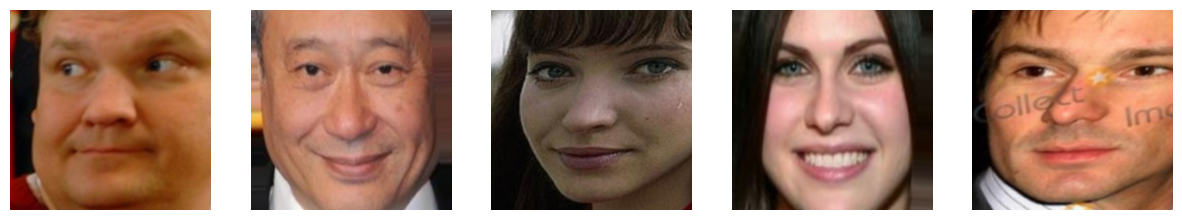

In [ ]:
images, _ = next(iter(train_loader))

batch_size = images.shape[0]
random_indices = torch.randperm(batch_size)[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, idx in enumerate(random_indices):
    img = images[idx].permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)

    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()

# 3. Обучение на CELoss

## 3.1. Подготовка модели

Для классификации лиц возьмём обученную на ImageNet'е нейросеть EfficientNetB0. Эта нейросеть хорошо работает с изображениями 224 на 224, поэтому мы делаем ресайз к этому размеру в классе датасета.

Выведем структуру модели.

In [ ]:
model = models.efficientnet_b0(weights='IMAGENET1K_V1')
model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 121MB/s] 


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Видем что структура это
- CNN состоящая из 8 блоков
- Классификатор в котором находится всего навсего 1 линейный слой, который просто выдаёт ответ.

Классификатор мы будем заменять на свой (просто заменим out_features на число людей у нас в датасете)

In [ ]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

## 3.2. Обучение модели

Сначала напишем функцию, которая будет размораживать нужные блоки модели и которая вернёт только обучаемые параметры

In [14]:
def unfreeze_blocks(model, n):
  blocks = list(model.features.children())

  for param in model.parameters():
    param.requires_grad = False

  for param in model.classifier.parameters():
    param.requires_grad = True

  if n > 0:
    for i in range(len(blocks)-n, len(blocks)):
      for param in blocks[i].parameters():
        param.requires_grad = True

  return model

def get_trainable_params(model):
  return filter(lambda p: p.requires_grad, model.parameters())

Теперь сетапим гиперпараметры. Разморозим последние 5 блоков (всего их 9 + классификатор), обучим на 30 эпох.

In [ ]:
model = unfreeze_blocks(model, 5)

params = get_trainable_params(model)
optimizer = optim.Adam(params, lr=3e-4)

num_epochs = 30

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-4,
    cooldown=2,
    min_lr=1e-6,
)

print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'


True


И непосредственно функция обучения модели

In [ ]:
from tqdm.notebook import tqdm

def train(model, optimizer, scheduler, train_loader, val_loader, criterion, num_epochs):
  train_loss = []
  val_loss = []

  best_val_loss = float('inf')
  save_path = '/content/drive/MyDrive/DLS Project Model Weights/CELoss_classifier.pth'

  model.to(device)

  for epoch in tqdm(range(num_epochs), desc=f'Epochs'):
    # Train
    model.train()
    epoch_train_loss = []

    for X_batch, y_batch in tqdm(train_loader, desc=f'Train'):
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      optimizer.zero_grad()
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      loss.backward()
      optimizer.step()

      epoch_train_loss.append(loss.item())

    epoch_train_loss = np.mean(epoch_train_loss)
    train_loss.append(epoch_train_loss)
    print(f'Train loss: {epoch_train_loss}\n')


    # Val
    model.eval()
    epoch_val_loss = []

    with torch.no_grad():
      for X_batch, y_batch in tqdm(val_loader, desc=f'Val'):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        epoch_val_loss.append(loss.item())

      epoch_val_loss = np.mean(epoch_val_loss)
      val_loss.append(epoch_val_loss)
      print(f'Val loss: {epoch_val_loss}\n')

      scheduler.step(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), save_path)

  return train_loss, val_loss

In [ ]:
train_loss, val_loss = train(model, optimizer, scheduler, train_loader, val_loader, criterion, num_epochs)

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Train:   0%|          | 0/1520 [00:00<?, ?it/s]

Train loss: 5.896477775824698



Val:   0%|          | 0/380 [00:00<?, ?it/s]

Val loss: 4.398584056527991



...

Val loss: 1.2108164718787424



Train:   0%|          | 0/1520 [00:00<?, ?it/s]

Train loss: 0.006722268166147746



Val:   0%|          | 0/380 [00:00<?, ?it/s]

Val loss: 1.1949908454135432



Графики обучения:

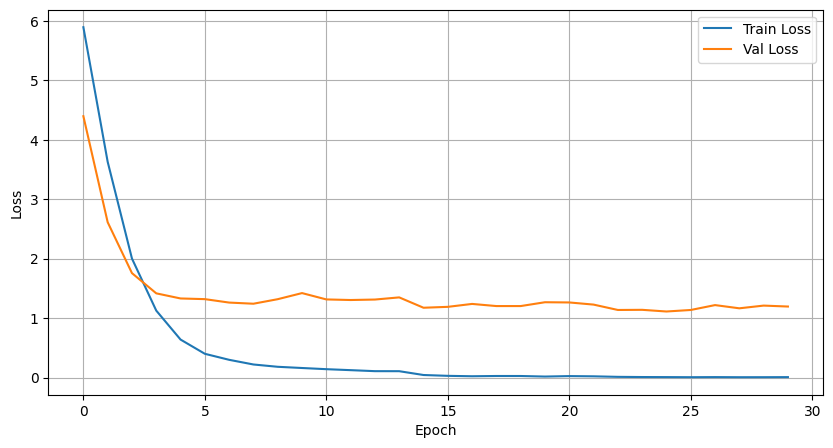

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 3.3. Подсчёт Accuracy

Посмотрим на accuracy обученной нами модели. Мы хотим получить хотя бы 0.7! Считаем его на val'e (у нас val=test, т.к. мы не пользуемся техниками кросс-валилации и прочим, то можно использовать его и так и так)

In [18]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.2 MB/s eta 0:00:00


In [ ]:
from torchmetrics.classification import Accuracy

accuracy = Accuracy(task='multiclass', num_classes=num_classes).to(device)

model.load_state_dict(torch.load('/content/drive/MyDrive/DLS Project Model Weights/CELoss_classifier.pth'))
model.to(device)
model.eval()

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred = model(X_batch)
        accuracy.update(y_pred, y_batch)

val_acc = accuracy.compute().item()
print(f'Accuracy: {val_acc*100:.2f}%')
accuracy.reset()

Accuracy: 82.26%


Итак мы добились accuracy ~ 0.8, что больше чем наш порог в 0.7!

# 4. Обучение на ArcFace

## 4.1. ArcFace слой

Реализуем для начала непосредственно ArcFace слой, которым мы заменим классификатор у EfficientNet B0. Гиперпараметры s и m мы берём как в оригинальной статье (64 и 0.5)

Для чииленной стабильности добавим трюк fallback (В начае обучения cos может быть близким к -1 и при добавлении m функция меняет характер монотонности, из-за чего мы начинаем штрафовать нашу модель тогда, когда мы должны поощрять)

In [11]:
class ArcFace(nn.Module):
    def __init__(self, embedding_size, num_classes, s=64.0, m=0.5):
        super(ArcFace, self).__init__()
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):
      embeddings = F.normalize(embeddings, p=2, dim=1)
      weight_norm = F.normalize(self.weight, p=2, dim=1)

      cos_theta = F.linear(embeddings, weight_norm)
      cos_theta = cos_theta.clamp(-1.0 + 1e-7, 1.0 - 1e-7)
      sin_theta = torch.sqrt((1.0 - cos_theta ** 2).clamp(min=1e-7))

      cos_m, sin_m = np.cos(self.m), np.sin(self.m)
      th = np.cos(np.pi - self.m)
      mm = np.sin(np.pi - self.m) * self.m

      one_hot = torch.zeros_like(cos_theta)
      if labels is not None:
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1.0)

      target_logits = cos_theta * cos_m - sin_theta * sin_m
      target_logits = torch.where(cos_theta > th, target_logits, cos_theta - mm)

      output = cos_theta * (1 - one_hot) + target_logits * one_hot
      output *= self.s

      return output


## 4.2. Модификация модели

Теперь делаем замену линейного слоя на ArcFace слой у EfficientNet

In [33]:
class ArcFaceEN(nn.Module):
  def __init__(self, backbone, num_classes, embedding_size=1280, s=64.0, m=0.5):
    super().__init__()
    self.backbone = backbone
    self.dropout = nn.Dropout(p=0.2, inplace=True)
    self.classifier = ArcFace(embedding_size, num_classes, s, m)

  def forward(self, x, labels, mode='arcface'):
    '''
    mode = 'arcface': Use ArcFace, return logits
    mode = 'work': Skip ArcFace, return embeddings
    '''
    embeddings = self.backbone(x)
    if mode == 'arcface':
      embeddings = self.dropout(embeddings)
      logits = self.classifier(embeddings, labels)
      return logits
    else:
      return F.normalize(embeddings, p=2, dim=1)


In [42]:
arcface_model = models.efficientnet_b0(weights='IMAGENET1K_V1')
arcface_model.classifier = nn.Identity()
arcface_model = unfreeze_blocks(arcface_model, 5)
arcface_model = ArcFaceEN(arcface_model, num_classes)

## 4.3. Обучение ArcFace модели

Обучим теперь модель точно так же как и предыдущую. Добавив CELoss наш слой можно называть ArcFace Loss'ом

In [43]:
arcface_params = get_trainable_params(arcface_model)
optimizer = optim.Adam(arcface_params, lr=3e-4)

num_epochs = 50

criterion = nn.CrossEntropyLoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    threshold=1e-4,
    cooldown=2,
    min_lr=1e-6,
)

print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'

True


In [22]:
from tqdm.notebook import tqdm

def arcface_train(model, optimizer, scheduler, train_loader, val_loader, criterion, num_epochs):
  train_loss = []
  val_loss = []

  best_val_loss = float('inf')
  save_path = '/content/drive/MyDrive/DLS Project Model Weights/ArcFace_classifier.pth'

  model.to(device)

  for epoch in tqdm(range(num_epochs), desc=f'Epochs'):
    # Train
    model.train()
    epoch_train_loss = []

    for X_batch, y_batch in tqdm(train_loader, desc=f'Train'):
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)

      optimizer.zero_grad()
      logits = model(X_batch, y_batch)
      loss = criterion(logits, y_batch)
      loss.backward()
      optimizer.step()

      epoch_train_loss.append(loss.item())

    epoch_train_loss = np.mean(epoch_train_loss)
    train_loss.append(epoch_train_loss)
    print(f'Train loss: {epoch_train_loss}\n')


    # Val
    model.eval()
    epoch_val_loss = []

    with torch.no_grad():
      for X_batch, y_batch in tqdm(val_loader, desc=f'Val'):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        logits = model(X_batch, y_batch)
        loss = criterion(logits, y_batch)

        epoch_val_loss.append(loss.item())

      epoch_val_loss = np.mean(epoch_val_loss)
      val_loss.append(epoch_val_loss)
      print(f'Val loss: {epoch_val_loss}\n')

      scheduler.step(epoch_val_loss)

    # Save best model
    if epoch_val_loss < best_val_loss:
      best_val_loss = epoch_val_loss
      torch.save(model.state_dict(), save_path)

  return train_loss, val_loss

P.S. И тут я заметил, что коллаб спокойно воспринимает батч сайз 256, когда каггл плакал уже на размере больше 8.

In [44]:
train_loss, val_loss = arcface_train(arcface_model, optimizer, scheduler, train_loader, val_loader, criterion, num_epochs)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Train:   0%|          | 0/48 [00:00<?, ?it/s]

Train loss: 37.92130637168884



Val:   0%|          | 0/12 [00:00<?, ?it/s]

Val loss: 36.451324144999184



...

Val loss: 17.859926382700603



Train:   0%|          | 0/48 [00:00<?, ?it/s]

Train loss: 0.5997713164736828



Val:   0%|          | 0/12 [00:00<?, ?it/s]

Val loss: 17.759554862976074



И конечно же график обучения

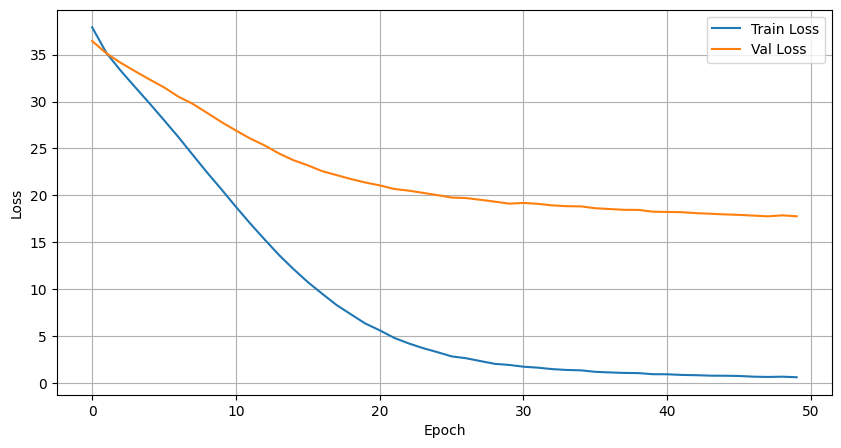

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 4.4. Подсчёт Accuracy

Посчитаем Accuracy на этой модели. Опять же хотим получить хотя бы 0.7

In [47]:
from torchmetrics.classification import Accuracy

accuracy = Accuracy(task='multiclass', num_classes=num_classes).to(device)

arcface_model.load_state_dict(torch.load('/content/drive/MyDrive/DLS Project Model Weights/ArcFace_classifier.pth'))
arcface_model.to(device)
arcface_model.eval()

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        y_pred = arcface_model(X_batch, None)
        accuracy.update(y_pred, y_batch)

val_acc = accuracy.compute().item()
print(f'Accuracy: {val_acc*100:.2f}%')
accuracy.reset()

Accuracy: 77.79%


Получили 77% что больше нашего порога!

# 5. Выводы

Итого мы получили 82% accuracy у модели обученной на CE Loss и 77% у модели обученной на ArcFace, т.е. мы добились достаточного качества классификации на обеих моделях

Однако - ArcFace более акутальный loss для задачи face recognition чем базовый CE Loss, почему мы получили качество ниже?

1. И там и там по лоссам видно, что модель так-то переобучивается. Проблема может крыться во многом: Размораживаем слишком много слоёв у EfficientNet B0, слишком высокий lr, неподходящий шедулер и т.п. В общем говоря - возможно стоит побольше побаловаться с гиперпараметрами, сделать более динамическое обучение (размараживать EfficientNet B0 постепенно, понижая lr) и т.д.

2. Возможно проблема в том, как мы решили строить датасет. У нас 15к изображений, где 800 людей, т.е. в среднем на каждого по 19 изображений. возможно столо брать меньше классов, но больше представителей. Видимо у ArcFace слишком мало преставителей класса чтобы выделять им отдельный телесный угол.